# Actividad: Análisis Exploratorio y Distribución Gaussiana
## Matemáticas Aplicadas a Ciencia de Datos

**Alumno:** Saúl Ibrahim García Morales  
**Licenciatura en Ciencia de Datos e Inteligencia Artificial**  
**Profesor:** Iván Alejandro Toledano Juárez  
**Semestre:** 2026B — Examen 1

---

## Contexto

Vamos a utilizar el dataset **Student Performance** que contiene información sobre estudiantes de matemáticas en dos escuelas portuguesas. El dataset incluye variables demográficas, sociales y académicas.

**Variables principales:**
- `G1`: Calificación del primer período (0-20)
- `G2`: Calificación del segundo período (0-20)
- `G3`: Calificación final (0-20) - **Variable objetivo**
- `studytime`: Tiempo de estudio semanal (1: <2 horas, 2: 2-5 horas, 3: 5-10 horas, 4: >10 horas)
- `absences`: Número de ausencias (0-93)
- `age`: Edad del estudiante (15-22)
- `failures`: Número de materias reprobadas anteriormente (0-4)


In [1]:
# Importar librerías necesarias
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats


In [2]:
# Cargar el dataset
df = pd.read_csv('student-mat.csv', sep=';')
df_global = df
df.head()


In [3]:
## Funciones de apoyo para visualización gaussiana estándar
def area_cdf(z):
    x = np.arange(-10, z, 0.001)
    x_full = np.arange(-10, 10, 0.001)
    plt.figure(figsize=(7, 3.5))
    plt.plot(x_full, stats.norm.pdf(x_full, 0, 1), color='#2563eb', linewidth=2)
    plt.fill_between(x, stats.norm.pdf(x, 0, 1), color='#3b82f6', alpha=0.5, label=f'Área acumulada (Z ≤ {z:.2f})')
    plt.title(f"Distribución Acumulada hasta Z = {z:.2f}", fontsize=12)
    plt.xlabel("Puntaje Z", fontsize=10)
    plt.ylabel("Densidad N(0, 1)", fontsize=10)
    plt.xlim(-4, 4)
    plt.grid(True, linestyle=":", alpha=0.6)
    plt.legend()
    plt.tight_layout()
    plt.show()

def area_between(z1, z2):
    x = np.arange(z1, z2, 0.001)
    x_full = np.arange(-10, 10, 0.001)
    plt.figure(figsize=(7, 3.5))
    plt.plot(x_full, stats.norm.pdf(x_full, 0, 1), color='#2563eb', linewidth=2)
    plt.fill_between(x, stats.norm.pdf(x, 0, 1), color='#10b981', alpha=0.5, label=f'Área entre [{z1:.2f}, {z2:.2f}]')
    plt.title(f"Área bajo la curva entre Z1 = {z1:.2f} y Z2 = {z2:.2f}", fontsize=12)
    plt.xlabel("Puntaje Z", fontsize=10)
    plt.ylabel("Densidad N(0, 1)", fontsize=10)
    plt.xlim(-4, 4)
    plt.grid(True, linestyle=":", alpha=0.6)
    plt.legend()
    plt.tight_layout()
    plt.show()

def area_cdf_c(z):
    x = np.arange(z, 10, 0.001)
    x_full = np.arange(-10, 10, 0.001)
    plt.figure(figsize=(7, 3.5))
    plt.plot(x_full, stats.norm.pdf(x_full, 0, 1), color='#2563eb', linewidth=2)
    plt.fill_between(x, stats.norm.pdf(x, 0, 1), color='#ef4444', alpha=0.5, label=f'Área complementaria (Z ≥ {z:.2f})')
    plt.title(f"Distribución Acumulada Complementaria desde Z = {z:.2f}", fontsize=12)
    plt.xlabel("Puntaje Z", fontsize=10)
    plt.ylabel("Densidad N(0, 1)", fontsize=10)
    plt.xlim(-4, 4)
    plt.grid(True, linestyle=":", alpha=0.6)
    plt.legend()
    plt.tight_layout()
    plt.show()


## 1. Análisis Exploratorio de Datos

### 1.1 Medidas de Tendencia Central y Dispersión

Para la variable **G3 (calificación final)**:

**a) Calcula la media, mediana y moda**


In [4]:
media_g3 = df['G3'].mean()
mediana_g3 = df['G3'].median()
moda_g3 = df['G3'].mode().iloc[0]

print(f"Media de G3:   {media_g3:.4f}")
print(f"Mediana de G3: {mediana_g3:.4f}")
print(f"Moda de G3:    {moda_g3}")


Media de G3:   10.4152
Mediana de G3: 11.0000
Moda de G3:    10


**b) Calcula la desviación estándar, varianza y rango intercuartílico (IQR)**


In [5]:
std_g3 = df['G3'].std()
var_g3 = df['G3'].var()
q1_g3 = df['G3'].quantile(0.25)
q3_g3 = df['G3'].quantile(0.75)
iqr_g3 = q3_g3 - q1_g3

print(f"Desviación estándar de G3:   {std_g3:.4f}")
print(f"Varianza de G3:              {var_g3:.4f}")
print(f"Primer Cuartil (Q1 - 25%):   {q1_g3:.2f}")
print(f"Tercer Cuartil (Q3 - 75%):   {q3_g3:.2f}")
print(f"Rango Intercuartílico (IQR): {iqr_g3:.2f}")


Desviación estándar de G3:   4.5814
Varianza de G3:              20.9896
Primer Cuartil (Q1 - 25%):   8.00
Tercer Cuartil (Q3 - 75%):   14.00
Rango Intercuartílico (IQR): 6.00


**c) Interpreta estos resultados: ¿Qué te dicen sobre el desempeño general de los estudiantes?**

*Respuesta:*

la calificación final promedio de los estudiantes se sitúa en **10.42 puntos**, con una mediana de **11.00 puntos** y una moda de **10** (en una escala de 0 a 20). esto refleja un desempeño general justo en el umbral aprobatorio mínimo institucional (10/20).

la dispersión es notable: la desviación estándar de **4.58 puntos** y un rango intercuartílico de **6.00 puntos** (el 50% central de los alumnos obtuvo notas entre 8 y 14) evidencian una población sumamente heterogénea. existe una brecha marcada entre un sector de alto rendimiento y una fracción vulnerable con calificaciones muy bajas o nulas.


### 1.2 Visualización

**a) Crea un histograma de la variable G3 con al menos 10 bins.**


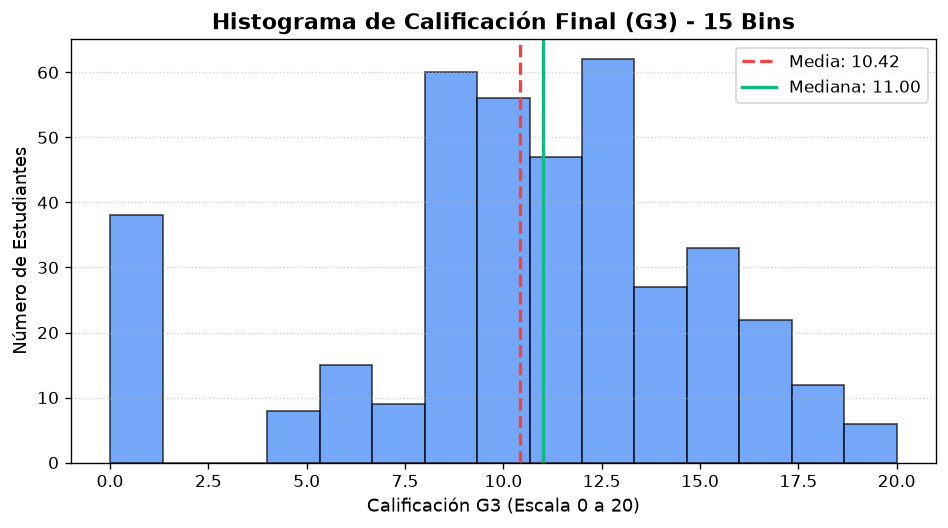

In [6]:
plt.figure(figsize=(8, 4.5))
plt.hist(df['G3'], bins=15, color='#3b82f6', edgecolor='black', alpha=0.7)
plt.axvline(df['G3'].mean(), color='#ef4444', linestyle='--', linewidth=2, label=f"Media: {df['G3'].mean():.2f}")
plt.axvline(df['G3'].median(), color='#10b981', linestyle='-', linewidth=2, label=f"Mediana: {df['G3'].median():.2f}")
plt.title("Histograma de Calificación Final (G3) - 15 Bins", fontsize=13, fontweight='bold')
plt.xlabel("Calificación G3 (Escala 0 a 20)", fontsize=11)
plt.ylabel("Número de Estudiantes", fontsize=11)
plt.legend(frameon=True)
plt.grid(axis='y', linestyle=':', alpha=0.6)
plt.tight_layout()


**b) Crea un boxplot de G3. Identifica si existen outliers y menciona cuántos hay.**


Límites de Tukey: [-1.00, 23.00]
Cantidad de outliers estadísticos fuera de los bigotes: 0


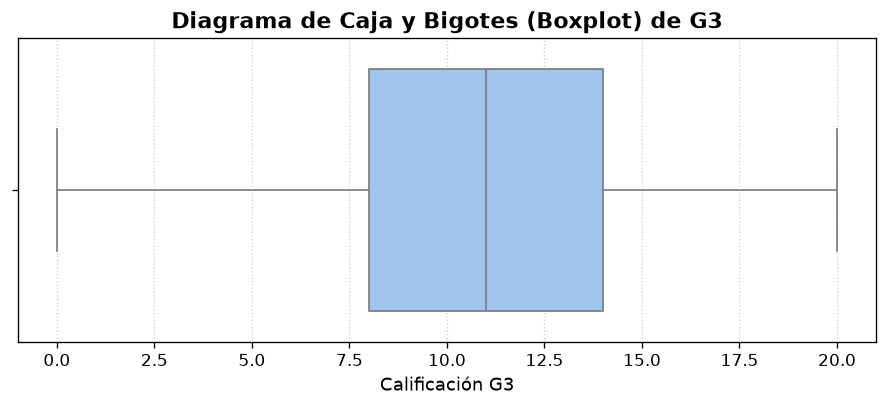

In [7]:
plt.figure(figsize=(7.5, 3.5))
sns.boxplot(x=df['G3'], color='#93c5fd', flierprops=dict(marker='o', markerfacecolor='#ef4444', markersize=8))
plt.title("Diagrama de Caja y Bigotes (Boxplot) de G3", fontsize=13, fontweight='bold')
plt.xlabel("Calificación G3", fontsize=11)
plt.grid(axis='x', linestyle=':', alpha=0.6)
plt.tight_layout()

# Conteo formal de outliers usando la regla de Tukey 1.5 * IQR
q1 = df['G3'].quantile(0.25)
q3 = df['G3'].quantile(0.75)
iqr = q3 - q1
lim_inf = q1 - 1.5 * iqr
lim_sup = q3 + 1.5 * iqr
outliers_g3 = df[(df['G3'] < lim_inf) | (df['G3'] > lim_sup)]
print(f"Límites de Tukey: [{lim_inf:.2f}, {lim_sup:.2f}]")
print(f"Cantidad de outliers estadísticos fuera de los bigotes: {len(outliers_g3)}")


*Respuesta:*

formalmente, bajo la regla de tukey ($1.5 \times \text{IQR}$), **no existen outliers estadísticos** (0 valores fuera de los bigotes). los límites de corte son $[-1.00, 23.00]$, y al estar las notas acotadas por diseño entre 0 y 20, todos los datos caen dentro de los bigotes.

sin embargo, a nivel operativo y contextual destaca un grupo de **38 estudiantes con calificación exactamente 0** (el 9.6% de la muestra). no son outliers en el boxplot porque el bigote inferior llega hasta 0, pero representan una anomalía académica (deserción o inasistencia al examen final) que altera fuertemente la distribución.


**c) Crea un scatter plot entre G2 (eje x) y G3 (eje y). ¿Qué relación observas?**


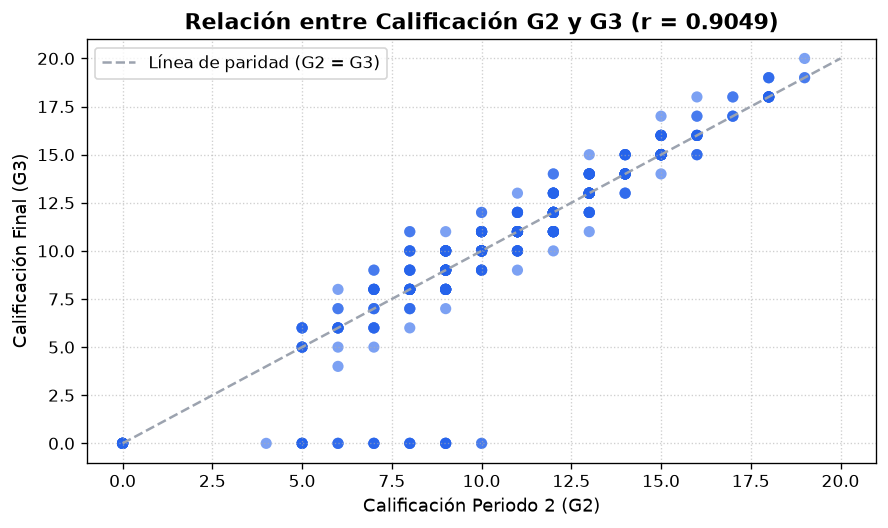

In [8]:
plt.figure(figsize=(7.5, 4.5))
plt.scatter(df['G2'], df['G3'], color='#2563eb', alpha=0.6, edgecolors='none', s=45)
plt.plot([0, 20], [0, 20], color='#9ca3af', linestyle='--', linewidth=1.5, label="Línea de paridad (G2 = G3)")
plt.title(f"Relación entre Calificación G2 y G3 (r = {df['G2'].corr(df['G3']):.4f})", fontsize=13, fontweight='bold')
plt.xlabel("Calificación Periodo 2 (G2)", fontsize=11)
plt.ylabel("Calificación Final (G3)", fontsize=11)
plt.legend()
plt.grid(True, linestyle=':', alpha=0.6)
plt.tight_layout()


*Respuesta:*

se observa una **relación lineal positiva sumamente fuerte** (coeficiente de correlación de pearson $r = 0.9049$). los alumnos con calificaciones altas en g2 obtienen casi de forma determinista calificaciones altas en g3. 

el único patrón discrepante son los puntos situados sobre la base inferior ($G3 = 0$ con $G2 \ge 8$), correspondientes a los estudiantes que llevaban buen ritmo en el segundo periodo pero que por abandono o faltas no presentaron la evaluación final.


### 1.3 Análisis de Distribución

**a) Observando el histograma de G3, ¿consideras que la distribución es aproximadamente simétrica, sesgada a la derecha o sesgada a la izquierda? Justifica tu respuesta**

*Respuesta:*

la distribución presenta una **asimetría leve a la izquierda (sesgo negativo)** producida por el cúmulo artificial de notas en cero. 

en el tramo principal ($G3 > 0$), la distribución adopta una silueta acampanada aproximadamente simétrica centrada alrededor de 10-12 puntos. sin embargo, la presencia del pico de 38 estudiantes con calificación 0 genera una cola artificial hacia los valores mínimos que rompe la simetría perfecta y alarga el extremo izquierdo.


**b) Compara la media y la mediana de G3. ¿Qué te indica esta comparación sobre la simetría de los datos? (5 puntos)**

*Respuesta:*

- **media**: $10.42$
- **mediana**: $11.00$

al cumplirse que **$\text{media} < \text{mediana}$** ($10.42 < 11.00$), se confirma cuantitativamente un **sesgo hacia la izquierda (asimetría negativa)**. 

la media es un estadístico sensible que es jalado hacia valores inferiores por los 38 ceros acumulados, mientras que la mediana, al ser una medida robusta e insensible a los valores extremos, conserva el punto donde se divide el 50% de la cohorte en 11.00.


---

## 2. Distribución Gaussiana

### 2.1 Ajuste de Distribución Normal

Considera la variable **G3 (calificación final)**.

**a) Estima los parámetros μ (media) y σ (desviación estándar) de una distribución normal que se ajuste a los datos de G3.**


In [9]:
mu_g3 = df['G3'].mean()
sigma_g3 = df['G3'].std()
mu_global = mu_g3
sigma_global = sigma_g3

print(f"Parámetro μ (Media estimada):                {mu_g3:.4f}")
print(f"Parámetro σ (Desviación estándar estimada):  {sigma_g3:.4f}")
print(f"Parámetro σ² (Varianza estimada):            {sigma_g3**2:.4f}")


Parámetro μ (Media estimada):                10.4152
Parámetro σ (Desviación estándar estimada):  4.5814
Parámetro σ² (Varianza estimada):            20.9896


**b) Crea un gráfico que superponga:**
- **El histograma normalizado (densidad) de G3**
- **La curva de la distribución normal N(μ, σ²) con los parámetros estimados**


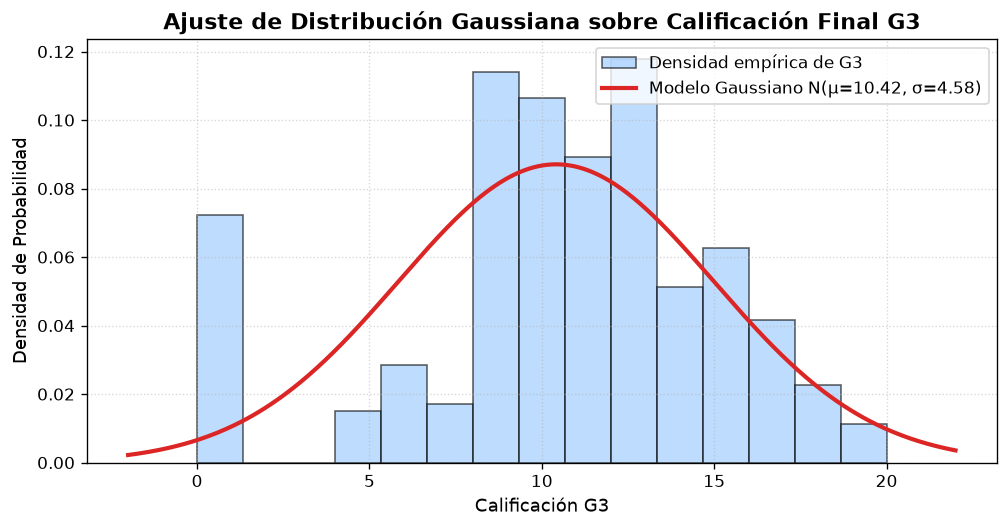

In [10]:
plt.figure(figsize=(8.5, 4.5))
plt.hist(df['G3'], bins=15, density=True, color='#93c5fd', edgecolor='black', alpha=0.6, label="Densidad empírica de G3")

x_domain = np.linspace(-2, 22, 400)
pdf_normal = stats.norm.pdf(x_domain, loc=mu_g3, scale=sigma_g3)
plt.plot(x_domain, pdf_normal, color='#dc2626', linewidth=2.5, label=f"Modelo Gaussiano N(μ={mu_g3:.2f}, σ={sigma_g3:.2f})")

plt.title("Ajuste de Distribución Gaussiana sobre Calificación Final G3", fontsize=13, fontweight='bold')
plt.xlabel("Calificación G3", fontsize=11)
plt.ylabel("Densidad de Probabilidad", fontsize=11)
plt.legend(frameon=True)
plt.grid(True, linestyle=':', alpha=0.5)
plt.tight_layout()


**c) Crea un gráfico Q-Q (quantile-quantile plot) para evaluar qué tan bien se ajusta G3 a una distribución normal. ¿Los datos siguen aproximadamente una distribución normal? Justifica.**


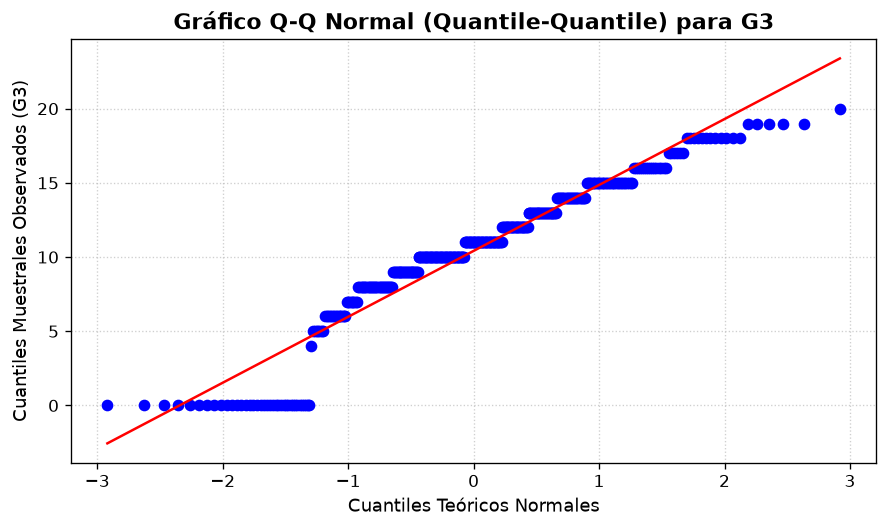

In [11]:
plt.figure(figsize=(7.5, 4.5))
stats.probplot(df['G3'], dist="norm", plot=plt)
plt.title("Gráfico Q-Q Normal (Quantile-Quantile) para G3", fontsize=13, fontweight='bold')
plt.xlabel("Cuantiles Teóricos Normales", fontsize=11)
plt.ylabel("Cuantiles Muestrales Observados (G3)", fontsize=11)
plt.grid(True, linestyle=':', alpha=0.6)
plt.tight_layout()


*Respuesta:*

los datos siguen **aproximadamente una distribución normal únicamente en la región central** (entre los cuantiles teóricos -1.0 y +1.5, notas de 6 a 16), donde los puntos se adhieren adecuadamente a la recta roja de 45°.

sin embargo, **no se ajusta globalmente a una distribución normal en los extremos**:
1. **cola inferior (izquierda)**: hay una desviación severa hacia abajo producida por el bloque de 38 estudiantes con calificación 0 (deserción o inasistencia), alejándose drásticamente de la normalidad.
2. **cola superior (derecha)**: la curva se aplana debido al techo rígido de 20 puntos en la escala de calificación.


### 2.2 Cálculo de Probabilidades

Asumiendo que G3 sigue una distribución normal con los parámetros estimados en 2.1:

**a) ¿Cuál es la probabilidad de que un estudiante seleccionado al azar obtenga una calificación final mayor a 15?**


Z-score para G3 = 15: 1.0007
Probabilidad P(G3 > 15): 0.1585 (15.85%)


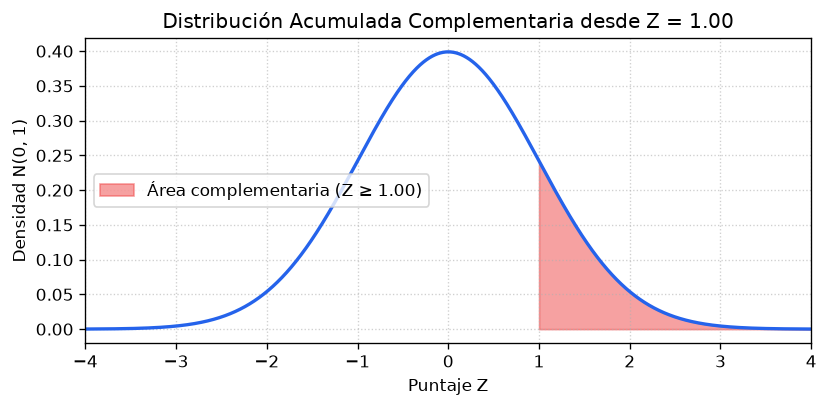

In [12]:
z_15 = (15 - mu_g3) / sigma_g3
prob_gt_15 = 1 - stats.norm.cdf(15, loc=mu_g3, scale=sigma_g3)

print(f"Z-score para G3 = 15: {z_15:.4f}")
print(f"Probabilidad P(G3 > 15): {prob_gt_15:.4f} ({prob_gt_15 * 100:.2f}%)")

area_cdf_c_impl(z_15)


**b) ¿Cuál es la probabilidad de que un estudiante obtenga una calificación entre 10 y 14?**


Z-score para G3 = 10: -0.0906
Z-score para G3 = 14: 0.7825
Probabilidad P(10 ≤ G3 ≤ 14): 0.3191 (31.91%)


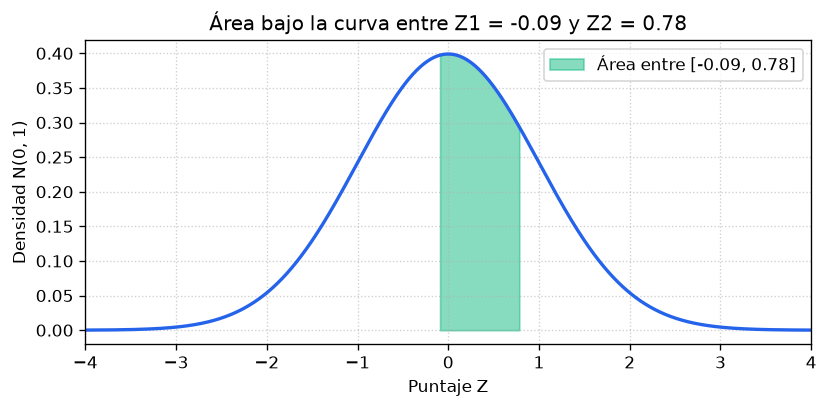

In [13]:
z_10 = (10 - mu_g3) / sigma_g3
z_14 = (14 - mu_g3) / sigma_g3
prob_10_14 = stats.norm.cdf(14, loc=mu_g3, scale=sigma_g3) - stats.norm.cdf(10, loc=mu_g3, scale=sigma_g3)

print(f"Z-score para G3 = 10: {z_10:.4f}")
print(f"Z-score para G3 = 14: {z_14:.4f}")
print(f"Probabilidad P(10 ≤ G3 ≤ 14): {prob_10_14:.4f} ({prob_10_14 * 100:.2f}%)")

area_between_impl(z_10, z_14)


**c) ¿Qué calificación representa el percentil 75? Es decir, ¿por debajo de qué calificación se encuentra el 75% de los estudiantes?**


In [14]:
p75_g3 = stats.norm.ppf(0.75, loc=mu_g3, scale=sigma_g3)
print(f"Percentil 75 (P75): {p75_g3:.4f} puntos (~{p75_g3:.2f})")
print(f"Interpretación: El 75% de los estudiantes tiene una calificación menor o igual a {p75_g3:.2f} puntos.")


Percentil 75 (P75): 13.5053 puntos (~13.51)
Interpretación: El 75% de los estudiantes tiene una calificación menor o igual a 13.51 puntos.


**d) Si se considera que un estudiante está "en riesgo" si su calificación está por debajo del percentil 25, ¿cuál es la calificación límite para estar en riesgo?**


In [15]:
p25_g3 = stats.norm.ppf(0.25, loc=mu_g3, scale=sigma_g3)
print(f"Percentil 25 (P25 - Umbral de Riesgo): {p25_g3:.4f} puntos (~{p25_g3:.2f})")
print(f"Calificación límite para estar en riesgo: {p25_g3:.2f} puntos")


Percentil 25 (P25 - Umbral de Riesgo): 7.3251 puntos (~7.33)
Calificación límite para estar en riesgo: 7.33 puntos


**e) ¿Cuál es la probabilidad de que un estudiante repruebe (G3 < 10)?**


Z-score para G3 = 10: -0.0906
Probabilidad de reprobar P(G3 < 10): 0.4639 (46.39%)


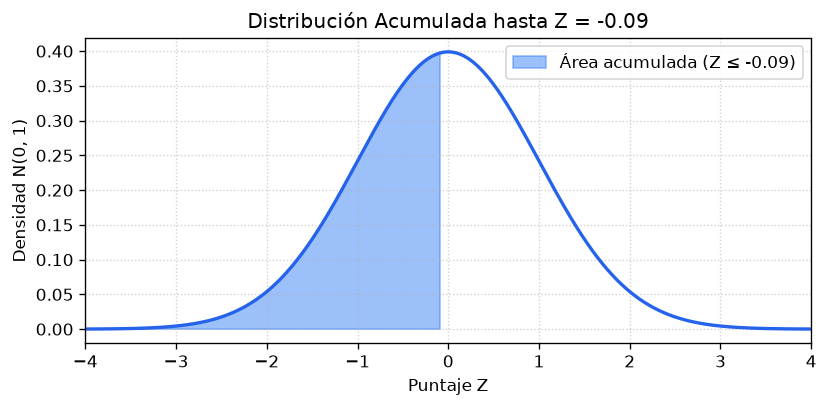

In [16]:
z_reprobar = (10 - mu_g3) / sigma_g3
prob_reprobar = stats.norm.cdf(10, loc=mu_g3, scale=sigma_g3)

print(f"Z-score para G3 = 10: {z_reprobar:.4f}")
print(f"Probabilidad de reprobar P(G3 < 10): {prob_reprobar:.4f} ({prob_reprobar * 100:.2f}%)")

area_cdf_impl(z_reprobar)


---

### 2.3 Interpretación y Aplicación

**a) Basándote en el modelo gaussiano ajustado, si la escuela tiene 500 estudiantes, ¿aproximadamente cuántos estudiantes esperarías que obtengan una calificación mayor a 16?**


Z-score para G3 = 16:                     1.2190
Probabilidad P(G3 > 16):                 0.1114 (11.14%)
Estudiantes esperados en cohorte de 500: 55.71 (~56 estudiantes)


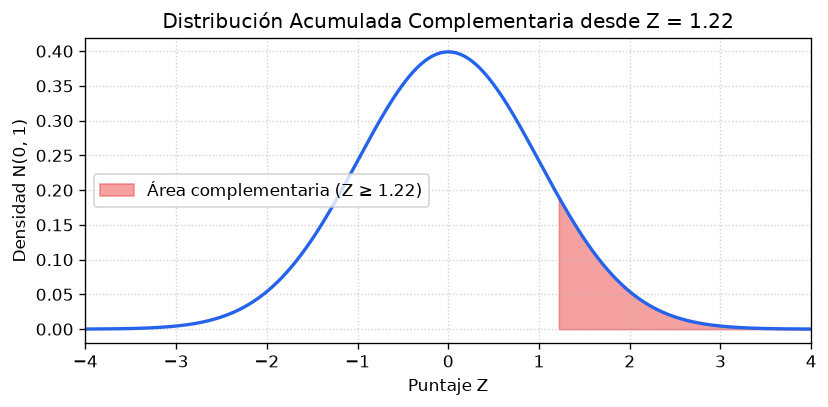

In [17]:
z_16 = (16 - mu_g3) / sigma_g3
prob_gt_16 = 1 - stats.norm.cdf(16, loc=mu_g3, scale=sigma_g3)
estudiantes_esperados_500 = 500 * prob_gt_16

print(f"Z-score para G3 = 16:                     {z_16:.4f}")
print(f"Probabilidad P(G3 > 16):                 {prob_gt_16:.4f} ({prob_gt_16 * 100:.2f}%)")
print(f"Estudiantes esperados en cohorte de 500: {estudiantes_esperados_500:.2f} (~{round(estudiantes_esperados_500)} estudiantes)")

area_cdf_c_impl(z_16)


**b) La escuela quiere implementar un programa de tutorías para el 20% de estudiantes con calificaciones más bajas. ¿Cuál debería ser la calificación de corte para seleccionar a estos estudiantes?**


In [18]:
corte_tutorias = stats.norm.ppf(0.20, loc=mu_g3, scale=sigma_g3)
print(f"Calificación de corte (Percentil 20): {corte_tutorias:.4f} puntos (~{corte_tutorias:.2f})")
print(f"Los alumnos con calificación G3 ≤ {corte_tutorias:.2f} deben ingresar al programa de tutorías.")


Calificación de corte (Percentil 20): 6.5594 puntos (~6.56)
Los alumnos con calificación G3 ≤ 6.56 deben ingresar al programa de tutorías.


**c) Reflexiona: ¿Consideras que el modelo de distribución normal es apropiado para modelar las calificaciones de los estudiantes? ¿Qué limitaciones podría tener este modelo?**

*Respuesta:*

el modelo de distribución normal es una herramienta teórica práctica y útil como primera aproximación paramétrica para estimar probabilidades y puntos de corte en poblaciones grandes. no obstante, para modelar calificaciones académicas presenta **tres limitaciones estructurales severas**:

1. **inconsistencia de soporte y rango (-∞ a +∞ vs 0 a 20)**: la campana de gauss se extiende infinitamente en ambos extremos, asignando probabilidades teóricas a calificaciones negativas ($G3 < 0$) o superiores al límite institucional ($G3 > 20$), lo cual es físicamente absurdo en el ámbito escolar.
2. **inflación de ceros por deserción (zero-inflation)**: el fenómeno de reprobación por abandono o inasistencia crea una concentración anómala de 38 ceros. este comportamiento bimodal no puede ser modelado por una normal unimodal pura y sesga artificialmente la media hacia abajo y agranda la varianza.
3. **naturaleza discreta**: las notas se evalúan en enteros discretos ($0, 1, 2, \dots, 20$), mientras que la función de densidad normal presupone una variable continua en los reales.


## Criterios de Evaluación

- **Justificación matemática y estadística**: 50%
- **Calidad del código y visualizaciones**: 25%
- **Interpretación y análisis crítico**: 25%

**Total: 100 puntos**
